In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Corona_NLP_train.csv', encoding='ISO-8859-1')
df[10:25]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
10,3809,48761,"Makati, Manila",16-03-2020,All month there hasn't been crowding in the su...,Neutral
11,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",Extremely Positive
12,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÂs ALL ...,Extremely Positive
13,3812,48764,"Chicago, IL",16-03-2020,"Me: I don't need to stock up on food, I'll jus...",Positive
14,3813,48765,NaN,16-03-2020,ADARA Releases COVID-19 Resource Center for Tr...,Positive
15,3814,48766,"Houston, Texas",16-03-2020,Lines at the grocery store have been unpredict...,Positive
16,3815,48767,Saudi Arabia,16-03-2020,????? ????? ????? ????? ??\r\r\n?????? ????? ?...,Neutral
17,3816,48768,"Ontario, Canada",16-03-2020,@eyeonthearctic 16MAR20 Russia consumer survei...,Neutral
18,3817,48769,North America,16-03-2020,"Amazon Glitch Stymies Whole Foods, Fresh Groce...",Extremely Positive
19,3818,48770,"Denver, CO",16-03-2020,"For those who aren't struggling, please consid...",Positive


In [5]:
# sample 1 under column "OriginalTweet"
df['OriginalTweet'][11]

'Due to the Covid-19 situation, we have increased demand for all food products. \r\r\n\r\r\nThe wait time may be longer for all online orders, particularly beef share and freezer packs. \r\r\n\r\r\nWe thank you for your patience during this time.'

with 100  nations inficted with  covid  19  the world must  not  play fair with china  100 goverments must demand  china  adopts new guilde  lines on food safty  the  chinese  goverment  is guilty of  being  irosponcible   with life  on a global scale

## Notes

What kind of processing is appropriate here? 

1. Language -- There is no good answer. Here, we will restrict to English, but what about mixed language tweets? 90%? (treat as hyperparameter?)
2. Misspellings and Slang -- These might not be processed correctly. So we should spell check (as best we can). But this will interfere with #1. 
3. Remove characters (excluding @ and #)
4. Keep the # and @ (these are essentially proxy topics!)


In [6]:
from textblob import TextBlob
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

`langdetect` does language testing for you, even with spelling issues. `langdetect` uses n-grams, which are sequences of characters or words, to build language profiles. Even if a text contains typos, some n-grams may still match the expected patterns for a particular language. For example, if a text has a typo like "helllo" instead of "hello," the n-grams "hell" and "llo" might still contribute to the detection of English. The probabilistic model is somewhat robust to minor typos because it considers the overall frequency of n-grams rather than requiring an exact match. However, severe or frequent typos can distort the n-gram frequencies, making it harder for the model to accurately detect the language.

`TextBlob` corrects text by focusing on spelling errors while preserving the original structure, including non-English words and special characters. However, it is important to be aware of its limitations, especially when dealing with multilingual text or context-specific corrections. For more advanced NLP tasks, you might need to combine `TextBlob` with other tools or libraries.

In [7]:
# Function to check if a tweet is in English
def is_english(text):
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

# Function to perform spell checking
def spell_check(text):
    blob = TextBlob(text)
    return str(blob.correct())

In [8]:
# check 
print(is_english(df['OriginalTweet'][20])) # the tweet with spelling errors 
print(spell_check(df['OriginalTweet'][20])) # the tweet with spelling errors
print(spell_check(df['OriginalTweet'][4])) # the tweet with spelling errors

True
with 100  nations infected with  could  19  the world must  not  play fair with china  100 governments must demand  china  adopt new guide  lines on food safety  the  chinese  government  is guilty of  being  irosponcible   with life  on a global scale
He, ready to go at supermarket during the #COVID19 outbreak.

Not because I'm paranoid, but because my food stock is literary empty. The #coronavirus is a serious thing, but please, don't panic. It causes shortage...

#CoronavirusFrance #restezchezvous #StayAtHome #confinement http://t.co/usmuaLq72n


In [9]:
# perform spell check on all tweets
df['OriginalTweet'] = df['OriginalTweet'].apply(lambda x: spell_check(x) if is_english(x) else x)


KeyboardInterrupt: 

In [10]:
# filter out non-English tweets
df = df[df['OriginalTweet'].apply(is_english)]

In [11]:
print(df['OriginalTweet'][10:20]) # peek at some tweets

10    All month there hasn't been crowding in the su...
11    Due to the Covid-19 situation, we have increas...
12    #horningsea is a caring community. LetÂs ALL ...
13    Me: I don't need to stock up on food, I'll jus...
14    ADARA Releases COVID-19 Resource Center for Tr...
15    Lines at the grocery store have been unpredict...
17    @eyeonthearctic 16MAR20 Russia consumer survei...
18    Amazon Glitch Stymies Whole Foods, Fresh Groce...
19    For those who aren't struggling, please consid...
20    with 100  nations inficted with  covid  19  th...
Name: OriginalTweet, dtype: object


Because we are focused more on meaning to analyze topics, we will use lemmatization over stemming; however, both are fine to use here. 

In [12]:
import re

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Preprocess tweet text for machine learning. 
    
    Done by removing URLs and special characters, tokenizing, removing 
    stop words, and lemmatizing the words.
    """
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove "&amp;" an HTML entity
    text = re.sub(r'&amp;', '', text)

    # Remove covid related words
    text = re.sub(r'covid|coronavirus', '', text, flags=re.IGNORECASE)

    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)

    # Tokenize the text
    tokens = nltk.word_tokenize(text)

    # Initialize the lemmatizer and stop words
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    # Remove stop words and lemmatize
    processed_tokens = [
        lemmatizer.lemmatize(token.lower())
        for token in tokens if token.lower() not in stop_words
    ]

    return ' '.join(processed_tokens)

In [13]:
# process tweets into tokens 
df['ProcessedTweet'] = df['OriginalTweet'].apply(preprocess_text)
print(df['ProcessedTweet'][10:20]) # peek at some tweets

10    month hasnt crowding supermarket restaurant ho...
11    due situation increased demand food product wa...
12    horningsea caring community let look less capa...
13    dont need stock food ill amazon deliver whatev...
14    adara release resource center travel brand ins...
15    line grocery store unpredictable eating safe a...
17    eyeonthearctic mar russia consumer surveillanc...
18    amazon glitch stymy whole food fresh grocery d...
19    arent struggling please consider donating food...
20    nation inficted world must play fair china gov...
Name: ProcessedTweet, dtype: object


In [15]:
from gensim import corpora
from gensim.models import LdaModel

def perform_lda(series, num_topics=3, passes=15, no_below=2, no_above=0.5, top_words=10):
    """
    Perform Latent Dirichlet Allocation (LDA) on a pandas Series of preprocessed text.

    Parameters:
    - series: pandas Series containing preprocessed text.
    - num_topics: Number of topics to identify.
    - passes: Number of passes through the corpus during training.
    - no_below: Keep tokens which are contained in at least `no_below` documents.
    - no_above: Keep tokens which are contained in no more than `no_above` documents (fraction of total corpus size).

    Returns:
    - topics: A list of topics with their top words.
    """

    texts = [text.split() for text in series]

    # Create a dictionary representation of the documents.
    dictionary = corpora.Dictionary(texts)

    # Filter out words that occur less than `no_below` documents, or more than `no_above` fraction of the documents.
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    # Create the corpus: a list of bags of words
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Build the LDA model
    lda_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=passes)

    # Extract topics and their top words
    topics = lda_model.print_topics(num_words=10)

    return topics, lda_model, dictionary, corpus

In [16]:
# apply LDA to the processed tweets
topics, model, dictionary, corpus = perform_lda(df['ProcessedTweet'], num_topics=8, passes=25, no_below=50, no_above=0.80, top_words=25)

In [18]:
# identify the topic for a tweet
def get_topic_for_tweet(tweet, model, dictionary):
    """
    Get the topic for a given tweet using the LDA model.

    Parameters:
    - tweet: The tweet text.
    - model: The trained LDA model.
    - dictionary: The dictionary used in the LDA model.

    Returns:
    - topic: The topic number assigned to the tweet.
    """
    # Tweets should be preprosessed in the same way as the training data!!
    
    # Convert the tweet to bag-of-words format
    bow = dictionary.doc2bow(tweet.split())
    
    # Get the topic distribution for the tweet
    topic_distribution = model.get_document_topics(bow)
    
    # Get the most probable topic
    topic = max(topic_distribution, key=lambda x: x[1])[0]
    
    return topic

In [20]:
get_topic_for_tweet(df['ProcessedTweet'][3], model, dictionary) # get topic for a tweet

6

In [21]:
# add column in dataframe for topic
df['Topic'] = df['ProcessedTweet'].apply(lambda x: get_topic_for_tweet(x, model, dictionary))

In [23]:
df[10:35]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,ProcessedTweet,Topic
10,3809,48761,"Makati, Manila",16-03-2020,All month there hasn't been crowding in the su...,Neutral,month hasnt crowding supermarket restaurant ho...,4
11,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",Extremely Positive,due situation increased demand food product wa...,6
12,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÂs ALL ...,Extremely Positive,horningsea caring community let look less capa...,5
13,3812,48764,"Chicago, IL",16-03-2020,"Me: I don't need to stock up on food, I'll jus...",Positive,dont need stock food ill amazon deliver whatev...,4
14,3813,48765,NaN,16-03-2020,ADARA Releases COVID-19 Resource Center for Tr...,Positive,adara release resource center travel brand ins...,2
15,3814,48766,"Houston, Texas",16-03-2020,Lines at the grocery store have been unpredict...,Positive,line grocery store unpredictable eating safe a...,5
17,3816,48768,"Ontario, Canada",16-03-2020,@eyeonthearctic 16MAR20 Russia consumer survei...,Neutral,eyeonthearctic mar russia consumer surveillanc...,2
18,3817,48769,North America,16-03-2020,"Amazon Glitch Stymies Whole Foods, Fresh Groce...",Extremely Positive,amazon glitch stymy whole food fresh grocery d...,6
19,3818,48770,"Denver, CO",16-03-2020,"For those who aren't struggling, please consid...",Positive,arent struggling please consider donating food...,6
20,3819,48771,southampton soxx xxx,16-03-2020,with 100 nations inficted with covid 19 th...,Extremely Negative,nation inficted world must play fair china gov...,2


In [ ]:
# print the topics
for topic in topics:
    print(topic)



(0, '0.037*"supermarket" + 0.031*"people" + 0.019*"need" + 0.018*"get" + 0.018*"dont" + 0.014*"know" + 0.014*"please" + 0.011*"like" + 0.011*"u" + 0.011*"think"')
(1, '0.034*"store" + 0.030*"supermarket" + 0.029*"grocer" + 0.023*"shopping" + 0.016*"go" + 0.016*"online" + 0.014*"socialdistancing" + 0.014*"people" + 0.014*"day" + 0.012*"home"')
(2, '0.059*"store" + 0.048*"worker" + 0.037*"grocer" + 0.021*"supermarket" + 0.017*"employee" + 0.015*"line" + 0.014*"work" + 0.014*"staff" + 0.013*"thank" + 0.013*"crockery"')
(3, '0.078*"food" + 0.036*"demand" + 0.031*"supply" + 0.026*"good" + 0.021*"panic" + 0.018*"stock" + 0.018*"buying" + 0.013*"bank" + 0.012*"chain" + 0.012*"need"')
(4, '0.068*"sanitizer" + 0.054*"hand" + 0.032*"toiletpaper" + 0.026*"paper" + 0.024*"mass" + 0.024*"toilet" + 0.019*"mask" + 0.016*"face" + 0.016*"corona" + 0.014*"glove"')
(5, '0.069*"consumer" + 0.025*"online" + 0.017*"shopping" + 0.017*"business" + 0.014*"anaemic" + 0.014*"new" + 0.012*"via" + 0.011*"report" +

In [ ]:
topics_df = pd.DataFrame(topics, columns=['Topic ID', 'Words'])
# Convert the words in each topic to a dictionary of word frequencies
topics_df['Words'] = topics_df['Words'].apply(lambda x: dict([word.split('*') for word in x.split(' + ')]))


In [ ]:
topics_df.head()

,Topic ID,Words
0,0,"{'0.037': '""supermarket""', '0.031': '""people""'..."
1,1,"{'0.034': '""store""', '0.030': '""supermarket""',..."
2,2,"{'0.059': '""store""', '0.048': '""worker""', '0.0..."
3,3,"{'0.078': '""food""', '0.036': '""demand""', '0.03..."
4,4,"{'0.068': '""sanitizer""', '0.054': '""hand""', '0..."


In [ ]:
# display words and frequencies in each topic
for index, row in topics_df.iterrows():
    print(f"Topic {row['Topic ID']}:")
    for word, freq in row['Words'].items():
        print(f"  {word}: {freq}")
    print()



Topic 0:
  0.037: "supermarket"
  0.031: "people"
  0.019: "need"
  0.018: "dont"
  0.014: "please"
  0.011: "think"

Topic 1:
  0.034: "store"
  0.030: "supermarket"
  0.029: "grocer"
  0.023: "shopping"
  0.016: "online"
  0.014: "day"
  0.012: "home"

Topic 2:
  0.059: "store"
  0.048: "worker"
  0.037: "grocer"
  0.021: "supermarket"
  0.017: "employee"
  0.015: "line"
  0.014: "staff"
  0.013: "crockery"

Topic 3:
  0.078: "food"
  0.036: "demand"
  0.031: "supply"
  0.026: "good"
  0.021: "panic"
  0.018: "buying"
  0.013: "bank"
  0.012: "need"

Topic 4:
  0.068: "sanitizer"
  0.054: "hand"
  0.032: "toiletpaper"
  0.026: "paper"
  0.024: "toilet"
  0.019: "mask"
  0.016: "corona"
  0.014: "glove"

Topic 5:
  0.069: "consumer"
  0.025: "online"
  0.017: "business"
  0.014: "new"
  0.012: "via"
  0.011: "change"
  0.010: "behavior"

Topic 6:
  0.061: "price"
  0.033: "oil"
  0.025: "market"
  0.021: "anaemic"
  0.018: "consumer"
  0.015: "global"
  0.014: "economy"
  0.012: "move

In [ ]:
from wordcloud import WordCloud

def visualize_dictionary(frequency_dict):
    """
    Visualize a dictionary using word clouds and bar charts.

    Parameter:
    - word_dict: Dictionary where keys are frequencies and values are words.
    """
    
    word_dict = {word.strip('"'): float(freq) for freq, word in frequency_dict.items()}

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_dict)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.grid(False)  # Remove grid lines
    plt.show()

    # Plot a bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(word_dict.keys(), word_dict.values(), color='skyblue')
    plt.title(f'Dictionary Top Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()


# Topic 0

/var/folders/3y/zq5zzw_17xj7dyw8dq_n2fg40000gp/T/ipykernel_82442/3732335547.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualize_dictionary(topics_df.iloc[0][1])


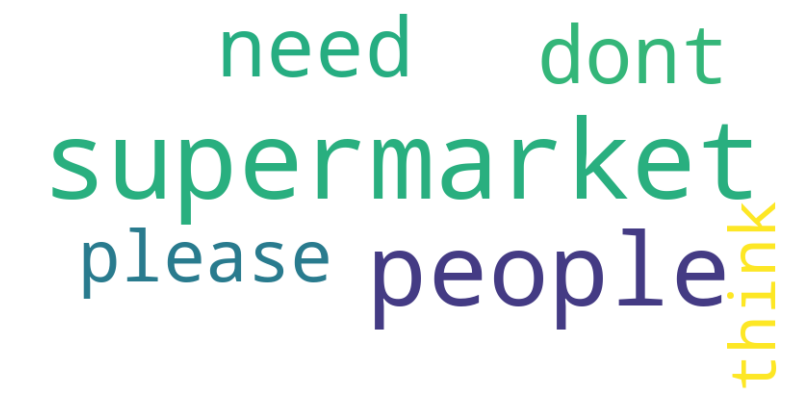

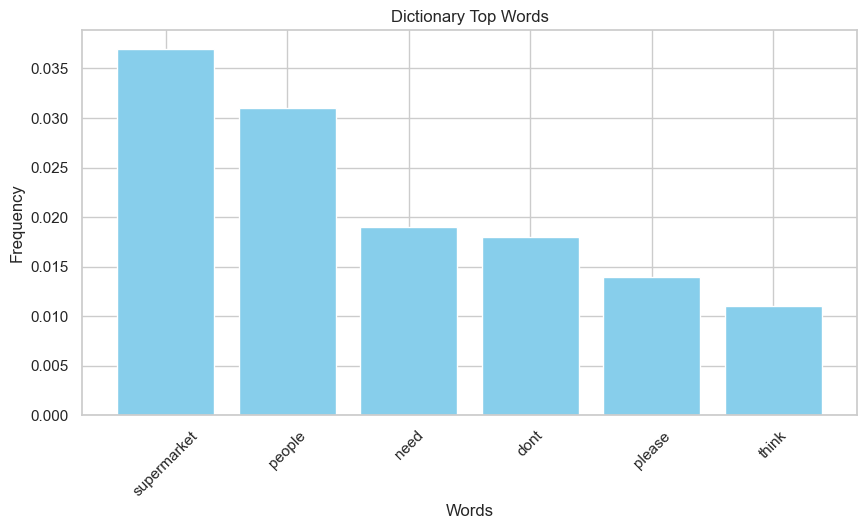

In [ ]:
# Topic 0 
visualize_dictionary(topics_df.iloc[0][1])

/var/folders/3y/zq5zzw_17xj7dyw8dq_n2fg40000gp/T/ipykernel_82442/4231667064.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualize_dictionary(topics_df.iloc[1][1])


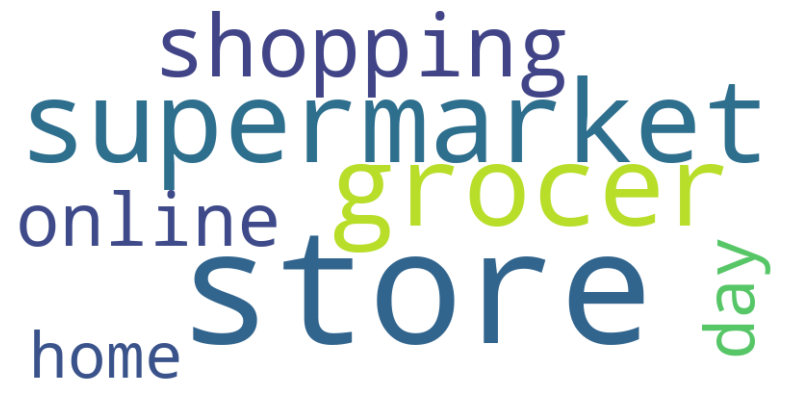

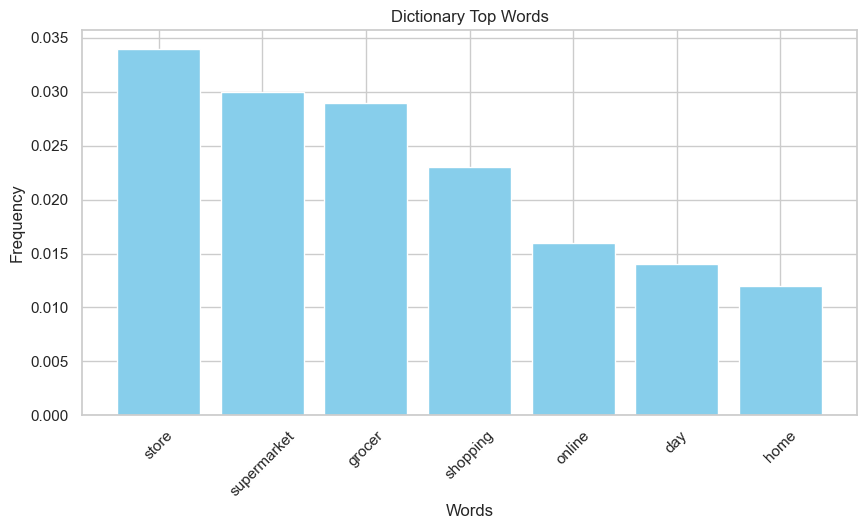

In [ ]:
# Topic 1
visualize_dictionary(topics_df.iloc[1][1])


/var/folders/3y/zq5zzw_17xj7dyw8dq_n2fg40000gp/T/ipykernel_82442/1438455836.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualize_dictionary(topics_df.iloc[2][1])


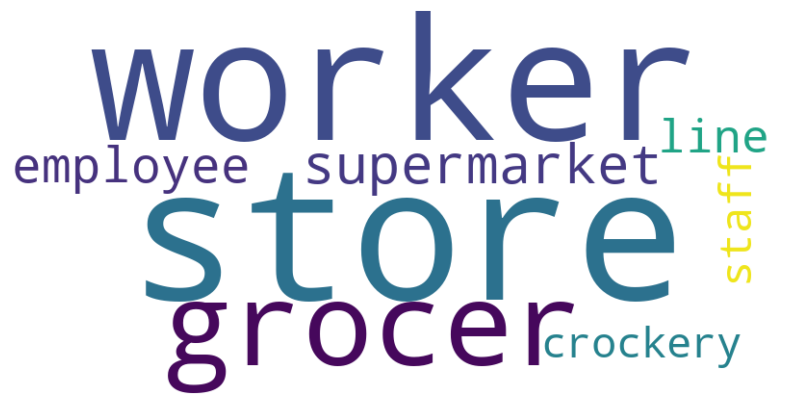

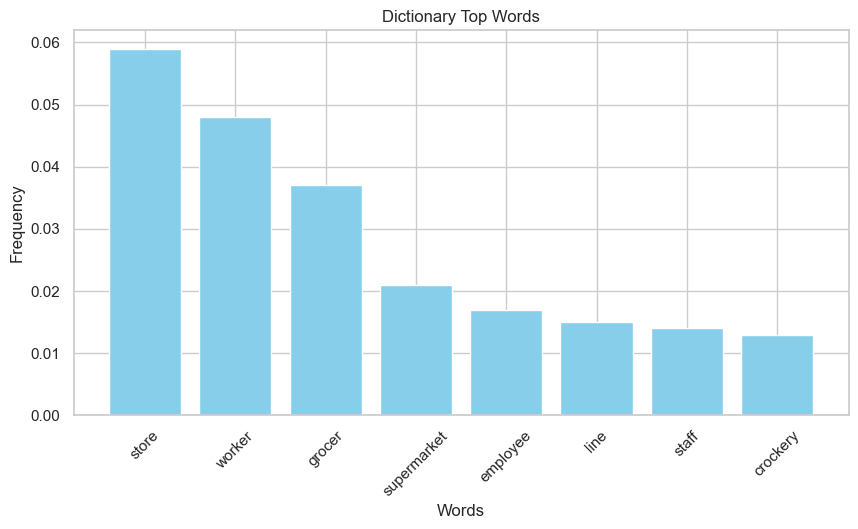

In [ ]:
# Topic 2
visualize_dictionary(topics_df.iloc[2][1])

/var/folders/3y/zq5zzw_17xj7dyw8dq_n2fg40000gp/T/ipykernel_82442/1376181632.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualize_dictionary(topics_df.iloc[3][1])


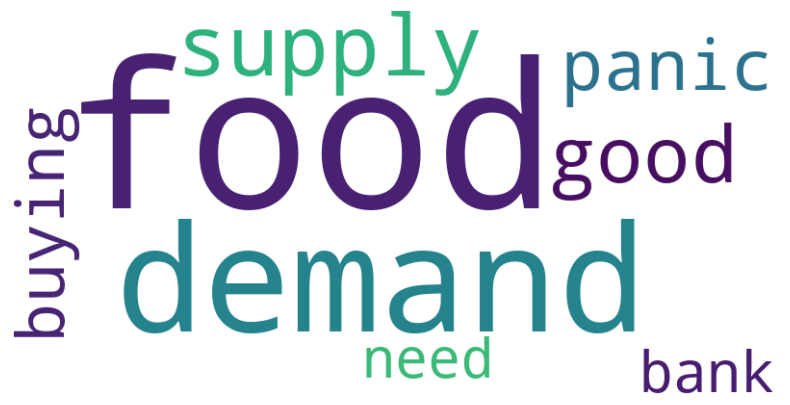

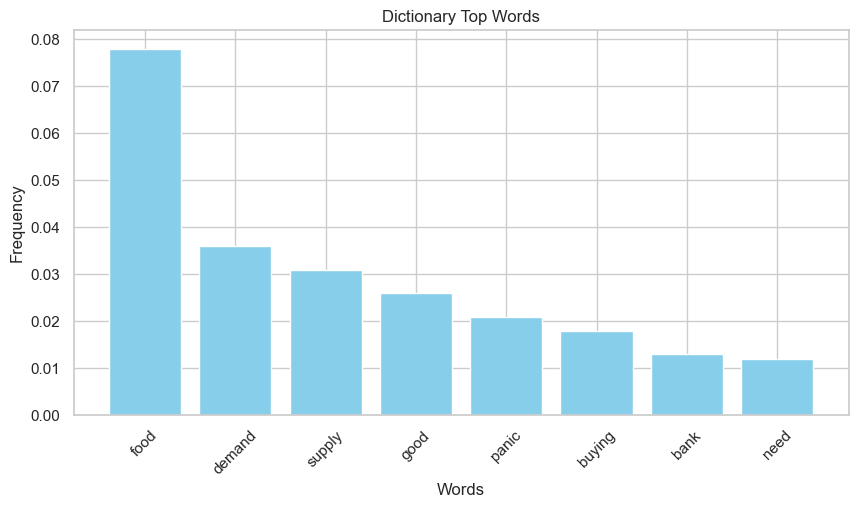

In [ ]:
# Topic 3
visualize_dictionary(topics_df.iloc[3][1])

/var/folders/3y/zq5zzw_17xj7dyw8dq_n2fg40000gp/T/ipykernel_82442/3552163452.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualize_dictionary(topics_df.iloc[4][1])


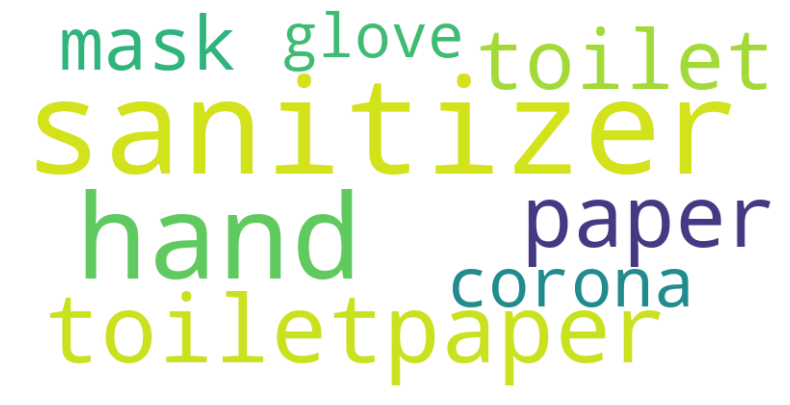

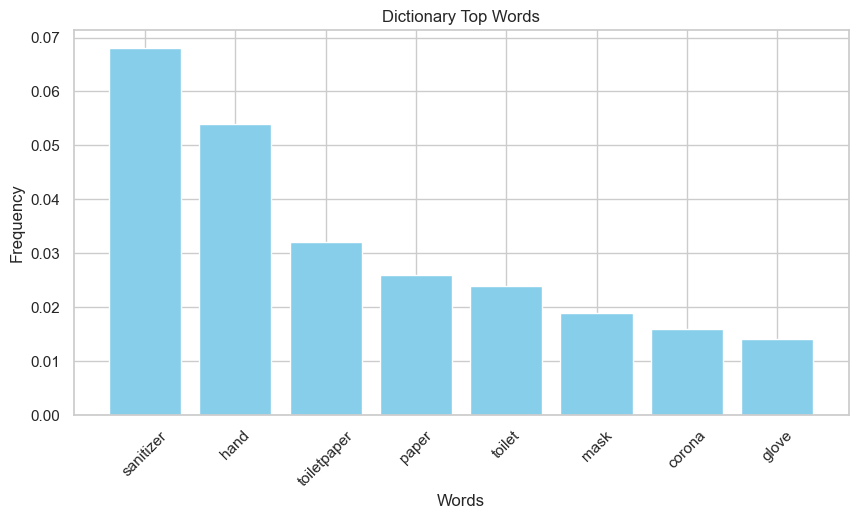

In [ ]:
# Topic 4
visualize_dictionary(topics_df.iloc[4][1])

/var/folders/3y/zq5zzw_17xj7dyw8dq_n2fg40000gp/T/ipykernel_82442/4146350391.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  visualize_dictionary(topics_df.iloc[5][1])


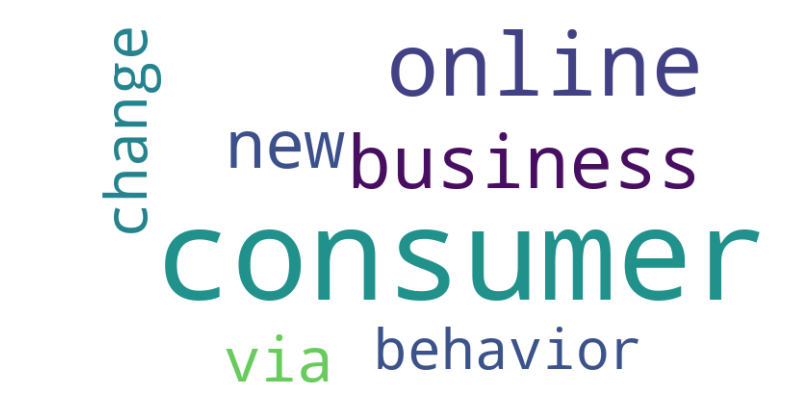

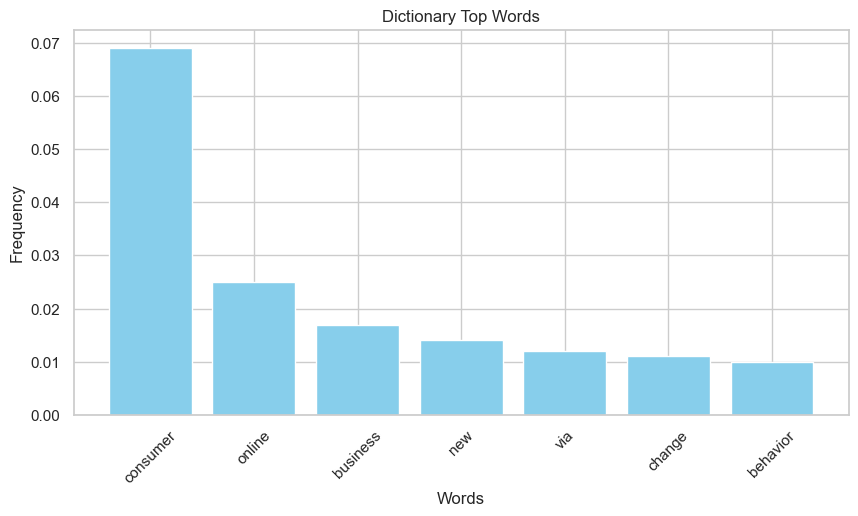

In [ ]:
# Topic 5
visualize_dictionary(topics_df.iloc[5][1])